In [1]:
# Four methods, each chosen because it matches the data:
#
#   1. LINEAR REGRESSION (supervised)
#      Three nested OLS models (M1/M2/M3) that directly test the
#      project's main hypothesis: does PM2.5 affect life expectancy,
#      and does HDI moderate that effect?
#
#   2. RANDOM FOREST REGRESSION (supervised)
#      Non-parametric corroboration of the linear models. Confirms
#      which features really matter and reveals any non-linearities.
#
#   3. K-MEANS CLUSTERING (unsupervised)
#      Finds natural groupings of countries based on
#      [PM2.5, HDI, LifeExp]. Elbow + silhouette pick k.
#
#   4. PCA (dimensionality reduction)
#      Projects the 3 numeric features into 2D for a single summary
#      scatter plot, colored by cluster, HDI group, and region.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.inspection      import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics         import r2_score, mean_squared_error, silhouette_score
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

In [4]:
# Load merged data and standardise column names
df = pd.read_csv("merged_dataset_2020.csv")
df = df.rename(columns={"PM2.5": "PM2_5"})
print(f"Loaded {len(df)} countries")
print(df.head())

Loaded 190 countries
       Country Code  Region      PM2_5    HDI  HDI_Group  LifeExp
0  Afghanistan  AFG    Asia  46.087094  0.501        Low  61.4537
1      Albania  ALB  Europe  15.707004  0.794       High  77.8241
2      Algeria  DZA  Africa  25.552656  0.742       High  73.2568
3      Andorra  AND  Europe   9.080281  0.851  Very High  79.4177
4       Angola  AGO  Africa  25.145238  0.610     Medium  63.1164


In [5]:
# Helper: OLS coefficient inference (manual, no statsmodels)
def ols_inference(X, y, feature_names):
    """
    Fit OLS by closed form and compute, for each coefficient:
      - estimate, standard error, t-statistic, two-sided p-value, 95% CI.
    Adds an intercept automatically.

    Returns a DataFrame and a dict of model R^2 / Adjusted R^2 / RMSE.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(y)

    X_ = np.column_stack([np.ones(n), X])
    p = X_.shape[1]
    df_resid = n - p

    XtX_inv = np.linalg.inv(X_.T @ X_)
    beta    = XtX_inv @ X_.T @ y
    y_hat   = X_ @ beta
    resid   = y - y_hat

    sse     = (resid ** 2).sum()
    sigma2  = sse / df_resid
    var_b   = sigma2 * XtX_inv
    se_b    = np.sqrt(np.diag(var_b))
    t_stat  = beta / se_b
    p_val   = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df_resid))
    t_crit  = stats.t.ppf(0.975, df=df_resid)
    ci_lo   = beta - t_crit * se_b
    ci_hi   = beta + t_crit * se_b

    table = pd.DataFrame({
        "feature":  ["Intercept"] + list(feature_names),
        "coef":     beta,
        "std_err":  se_b,
        "t":        t_stat,
        "p_value":  p_val,
        "ci_2.5%":  ci_lo,
        "ci_97.5%": ci_hi,
    })

    sst    = ((y - y.mean()) ** 2).sum()
    r2     = 1 - sse / sst
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p)
    rmse   = np.sqrt(sse / n)

    return table, {"n": n, "p": p, "R2": r2, "Adj_R2": adj_r2, "RMSE": rmse}


def cv_scores(model, X, y, k=5):
    """Return (mean_R2, sd_R2, mean_RMSE, sd_RMSE) under k-fold CV."""
    cv = KFold(n_splits=k, shuffle=True, random_state=42)
    r2_scores   = cross_val_score(model, X, y, cv=cv, scoring="r2")
    rmse_scores = -cross_val_score(model, X, y, cv=cv,
                                   scoring="neg_root_mean_squared_error")
    return r2_scores.mean(), r2_scores.std(), rmse_scores.mean(), rmse_scores.std()

In [6]:
# METHOD 1 - LINEAR REGRESSION
# =============================================================
# M1: LifeExp ~ PM2.5  (no controls, "raw" effect)
# =============================================================
print("\n" + "="*60)
print("METHOD 1 - LINEAR REGRESSION")
print("="*60)
print("\nM1: LifeExp ~ PM2.5")
print("-"*60)

X1 = df[["PM2_5"]].values
y  = df["LifeExp"].values

table1, fit1 = ols_inference(X1, y, ["PM2_5"])
cv1 = cv_scores(LinearRegression(), X1, y)
print(table1.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\n  n = {fit1['n']}   R2 = {fit1['R2']:.4f}   Adj.R2 = {fit1['Adj_R2']:.4f}"
      f"   RMSE = {fit1['RMSE']:.3f} years")
print(f"  5-fold CV R2 = {cv1[0]:.4f}  (sd {cv1[1]:.4f})")


METHOD 1 - LINEAR REGRESSION

M1: LifeExp ~ PM2.5
------------------------------------------------------------
  feature    coef  std_err       t  p_value  ci_2.5%  ci_97.5%
Intercept 77.2814   0.8836 87.4640   0.0000  75.5384   79.0244
    PM2_5 -0.2325   0.0311 -7.4794   0.0000  -0.2939   -0.1712

  n = 190   R2 = 0.2293   Adj.R2 = 0.2252   RMSE = 6.392 years
  5-fold CV R2 = 0.1720  (sd 0.1718)


In [7]:
# M2 - LifeExp ~ PM2.5 + HDI  (controls for HDI - confounding test)
print("\nM2: LifeExp ~ PM2.5 + HDI")
print("-"*60)

X2 = df[["PM2_5", "HDI"]].values
table2, fit2 = ols_inference(X2, y, ["PM2_5", "HDI"])
cv2 = cv_scores(LinearRegression(), X2, y)
print(table2.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\n  n = {fit2['n']}   R2 = {fit2['R2']:.4f}   Adj.R2 = {fit2['Adj_R2']:.4f}"
      f"   RMSE = {fit2['RMSE']:.3f} years")
print(f"  5-fold CV R2 = {cv2[0]:.4f}  (sd {cv2[1]:.4f})")


M2: LifeExp ~ PM2.5 + HDI
------------------------------------------------------------
  feature    coef  std_err       t  p_value  ci_2.5%  ci_97.5%
Intercept 37.7168   1.6518 22.8334   0.0000  34.4582   40.9754
    PM2_5  0.0238   0.0183  1.3045   0.1937  -0.0122    0.0598
      HDI 45.8904   1.8506 24.7982   0.0000  42.2397   49.5410

  n = 190   R2 = 0.8203   Adj.R2 = 0.8184   RMSE = 3.087 years
  5-fold CV R2 = 0.8062  (sd 0.0600)


In [8]:
# M3 - LifeExp ~ PM2.5_c + HDI_c + (PM2.5_c x HDI_c)
#                  (formal MODERATION test, mean-centered)
print("\nM3: LifeExp ~ PM2.5_c + HDI_c + PM2.5_c x HDI_c")
print("-"*60)
print("Variables are mean-centered so main effects represent the")
print("effect at the AVERAGE value of the other variable.\n")

pm_c   = df["PM2_5"] - df["PM2_5"].mean()
hdi_c  = df["HDI"]   - df["HDI"].mean()
inter  = pm_c * hdi_c

X3 = np.column_stack([pm_c, hdi_c, inter])
table3, fit3 = ols_inference(X3, y, ["PM2_5_c", "HDI_c", "PM2_5_c x HDI_c"])
cv3 = cv_scores(LinearRegression(), X3, y)
print(table3.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\n  n = {fit3['n']}   R2 = {fit3['R2']:.4f}   Adj.R2 = {fit3['Adj_R2']:.4f}"
      f"   RMSE = {fit3['RMSE']:.3f} years")
print(f"  5-fold CV R2 = {cv3[0]:.4f}  (sd {cv3[1]:.4f})")


M3: LifeExp ~ PM2.5_c + HDI_c + PM2.5_c x HDI_c
------------------------------------------------------------
Variables are mean-centered so main effects represent the
effect at the AVERAGE value of the other variable.

        feature    coef  std_err        t  p_value  ci_2.5%  ci_97.5%
      Intercept 71.6222   0.2527 283.3849   0.0000  71.1236   72.1208
        PM2_5_c  0.0221   0.0188   1.1740   0.2419  -0.0150    0.0592
          HDI_c 45.9400   1.8588  24.7144   0.0000  42.2729   49.6071
PM2_5_c x HDI_c -0.0360   0.0897  -0.4017   0.6884  -0.2130    0.1410

  n = 190   R2 = 0.8204   Adj.R2 = 0.8176   RMSE = 3.085 years
  5-fold CV R2 = 0.8051  (sd 0.0596)


In [9]:
# M1/M2/M3 comparison + diagnostic plots
print("\n" + "-"*60)
print("LINEAR-REGRESSION MODEL COMPARISON")
print("-"*60)
lr_compare = pd.DataFrame({
    "Model":    ["M1: PM2.5 only",
                 "M2: PM2.5 + HDI",
                 "M3: PM2.5 + HDI + PM2.5 x HDI"],
    "R2":       [fit1["R2"],     fit2["R2"],     fit3["R2"]],
    "Adj_R2":   [fit1["Adj_R2"], fit2["Adj_R2"], fit3["Adj_R2"]],
    "RMSE_yrs": [fit1["RMSE"],   fit2["RMSE"],   fit3["RMSE"]],
    "CV_R2":    [cv1[0], cv2[0], cv3[0]],
})
print(lr_compare.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


------------------------------------------------------------
LINEAR-REGRESSION MODEL COMPARISON
------------------------------------------------------------
                        Model     R2  Adj_R2  RMSE_yrs  CV_R2
               M1: PM2.5 only 0.2293  0.2252    6.3921 0.1720
              M2: PM2.5 + HDI 0.8203  0.8184    3.0867 0.8062
M3: PM2.5 + HDI + PM2.5 x HDI 0.8204  0.8176    3.0853 0.8051


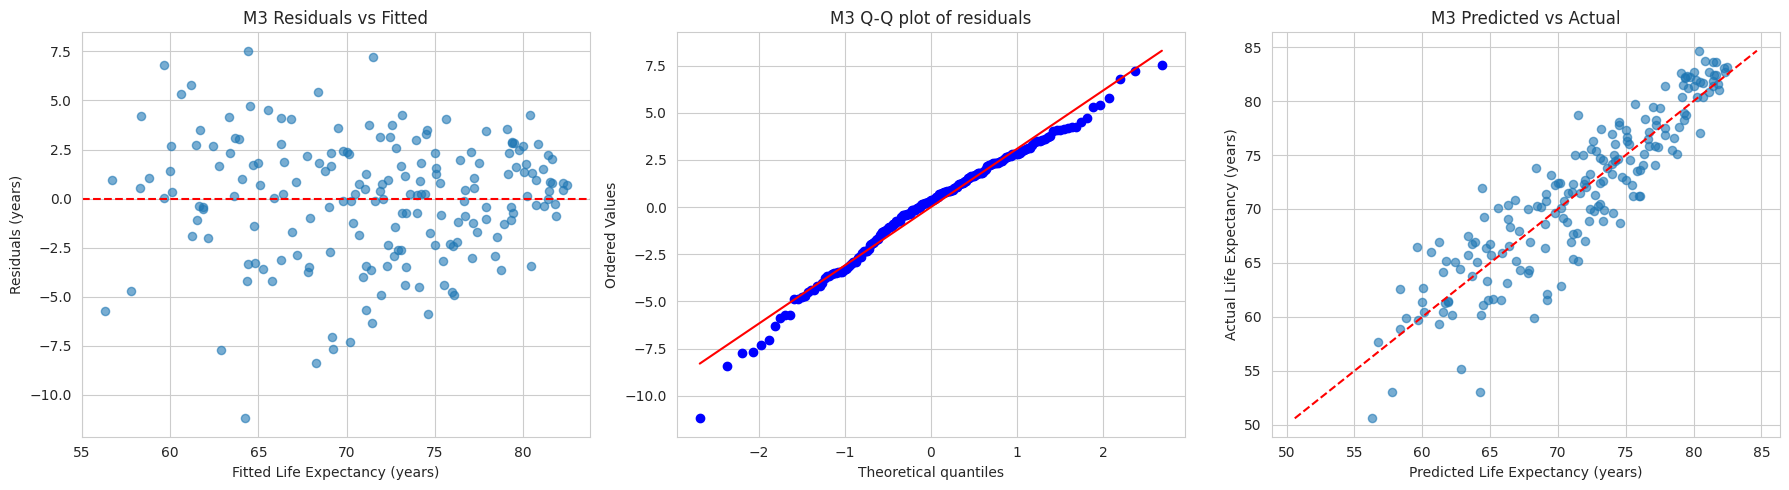

In [10]:
# Diagnostic plots for the most complete linear model (M3)
beta3  = np.linalg.lstsq(np.column_stack([np.ones(len(y)), X3]), y, rcond=None)[0]
y_hat3 = np.column_stack([np.ones(len(y)), X3]) @ beta3
resid3 = y - y_hat3

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_hat3, resid3, alpha=0.6, s=35)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Life Expectancy (years)")
axes[0].set_ylabel("Residuals (years)")
axes[0].set_title("M3 Residuals vs Fitted")

stats.probplot(resid3, dist="norm", plot=axes[1])
axes[1].set_title("M3 Q-Q plot of residuals")

axes[2].scatter(y_hat3, y, alpha=0.6, s=35)
lo, hi = y.min(), y.max()
axes[2].plot([lo, hi], [lo, hi], "r--")
axes[2].set_xlabel("Predicted Life Expectancy (years)")
axes[2].set_ylabel("Actual Life Expectancy (years)")
axes[2].set_title("M3 Predicted vs Actual")
plt.tight_layout(); plt.show()


------------------------------------------------------------
HOW THE PM2.5 COEFFICIENT CHANGES ACROSS MODELS
------------------------------------------------------------
If HDI is a confounder, the PM2.5 coefficient should shrink
substantially once HDI is added to the model.

            Model  PM2.5 coef  PM2.5 p-value
   M1: PM2.5 only     -0.2325      2.771e-12
        M2: + HDI     0.02382         0.1937
M3: + interaction     0.02208         0.2419



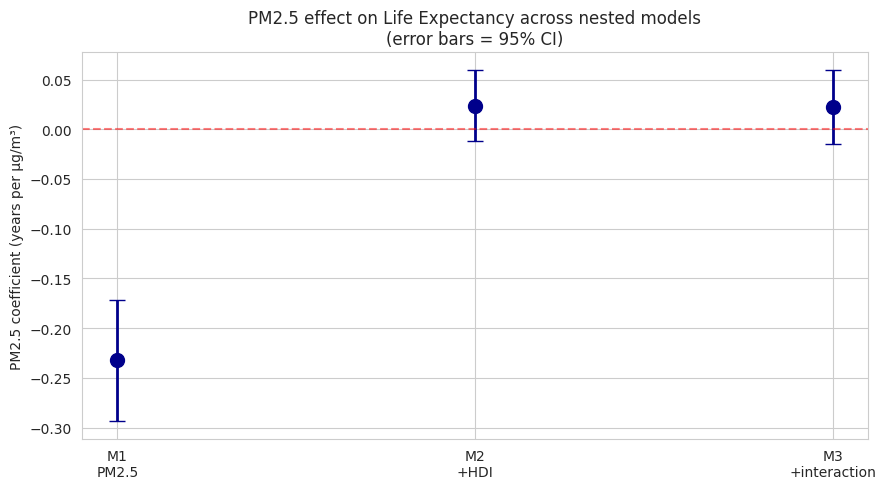

In [12]:
# How the PM2.5 coefficient changes across M1/M2/M3
print("\n" + "-"*60)
print("HOW THE PM2.5 COEFFICIENT CHANGES ACROSS MODELS")
print("-"*60)
print("If HDI is a confounder, the PM2.5 coefficient should shrink")
print("substantially once HDI is added to the model.\n")

pm_coef = pd.DataFrame({
    "Model":           ["M1: PM2.5 only", "M2: + HDI", "M3: + interaction"],
    "PM2.5 coef":      [table1.loc[1, "coef"],
                        table2.loc[1, "coef"],
                        table3.loc[1, "coef"]],
    "PM2.5 p-value":   [table1.loc[1, "p_value"],
                        table2.loc[1, "p_value"],
                        table3.loc[1, "p_value"]],
})
print(pm_coef.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

print()

fig, ax = plt.subplots(figsize=(9, 5))
labels  = ["M1\nPM2.5", "M2\n+HDI", "M3\n+interaction"]
coefs   = [table1.loc[1, "coef"],     table2.loc[1, "coef"],     table3.loc[1, "coef"]]
ci_los  = [table1.loc[1, "ci_2.5%"],  table2.loc[1, "ci_2.5%"],  table3.loc[1, "ci_2.5%"]]
ci_his  = [table1.loc[1, "ci_97.5%"], table2.loc[1, "ci_97.5%"], table3.loc[1, "ci_97.5%"]]
errors  = [np.array(coefs) - np.array(ci_los), np.array(ci_his) - np.array(coefs)]
ax.errorbar(labels, coefs, yerr=errors, fmt="o", color="darkblue",
            markersize=10, capsize=6, lw=2)
ax.axhline(0, color="red", linestyle="--", alpha=0.5)
ax.set_ylabel("PM2.5 coefficient (years per µg/m³)")
ax.set_title("PM2.5 effect on Life Expectancy across nested models\n"
             "(error bars = 95% CI)")
plt.tight_layout(); plt.show()

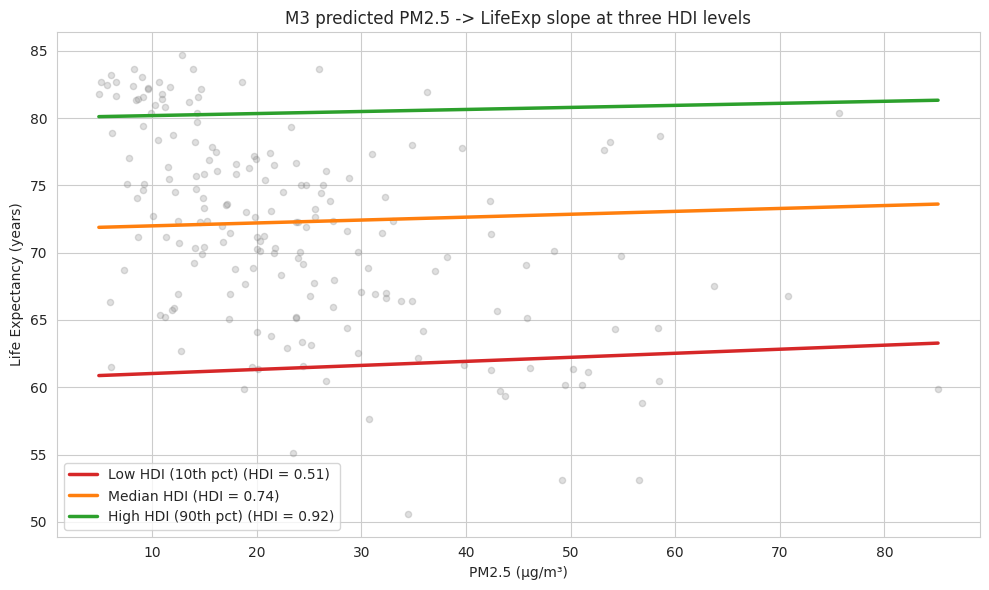

In [13]:
# Moderation visualisation: predicted slopes at different HDI levels
hdi_values = np.quantile(df["HDI"], [0.10, 0.50, 0.90])
hdi_labels = ["Low HDI (10th pct)", "Median HDI", "High HDI (90th pct)"]
pm_grid    = np.linspace(df["PM2_5"].min(), df["PM2_5"].max(), 100)

fig, ax = plt.subplots(figsize=(10, 6))
palette = ["#d62728", "#ff7f0e", "#2ca02c"]
for hdi_val, label, color in zip(hdi_values, hdi_labels, palette):
    pm_c_grid  = pm_grid - df["PM2_5"].mean()
    hdi_c_grid = hdi_val - df["HDI"].mean()
    Xg = np.column_stack([np.ones(100), pm_c_grid,
                          np.full(100, hdi_c_grid),
                          pm_c_grid * hdi_c_grid])
    y_pred = Xg @ beta3
    ax.plot(pm_grid, y_pred, lw=2.5, color=color,
            label=f"{label} (HDI = {hdi_val:.2f})")

ax.scatter(df["PM2_5"], df["LifeExp"], alpha=0.25, s=20, color="gray")
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("Life Expectancy (years)")
ax.set_title("M3 predicted PM2.5 -> LifeExp slope at three HDI levels")
ax.legend()
plt.tight_layout(); plt.show()

In [14]:
# Sensitivity analysis: linear models without Gulf states
print("\n" + "-"*60)
print("SENSITIVITY ANALYSIS - Linear models without Gulf states")
print("-"*60)
gulf_codes = ["QAT", "BHR", "KWT", "ARE", "SAU", "OMN"]
df_ng = df[~df["Code"].isin(gulf_codes)].copy()
y_ng  = df_ng["LifeExp"].values
print(f"Sample size: {len(df)} -> {len(df_ng)}\n")

X2_ng = df_ng[["PM2_5", "HDI"]].values
table2_ng, fit2_ng = ols_inference(X2_ng, y_ng, ["PM2_5", "HDI"])

print("M2 without Gulf:  LifeExp ~ PM2.5 + HDI")
print(table2_ng.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"  R2 = {fit2_ng['R2']:.4f}   Adj.R2 = {fit2_ng['Adj_R2']:.4f}\n")

print("PM2.5 coefficient comparison (M2):")
print(f"  With Gulf    :  coef = {table2.loc[1,'coef']:+.4f}   p = {table2.loc[1,'p_value']:.4f}")
print(f"  Without Gulf :  coef = {table2_ng.loc[1,'coef']:+.4f}   p = {table2_ng.loc[1,'p_value']:.4f}")


------------------------------------------------------------
SENSITIVITY ANALYSIS - Linear models without Gulf states
------------------------------------------------------------
Sample size: 190 -> 184

M2 without Gulf:  LifeExp ~ PM2.5 + HDI
  feature    coef  std_err       t  p_value  ci_2.5%  ci_97.5%
Intercept 37.8473   1.9759 19.1543   0.0000  33.9485   41.7461
    PM2_5  0.0223   0.0227  0.9845   0.3262  -0.0224    0.0671
      HDI 45.7486   2.1628 21.1528   0.0000  41.4811   50.0160
  R2 = 0.8145   Adj.R2 = 0.8124

PM2.5 coefficient comparison (M2):
  With Gulf    :  coef = +0.0238   p = 0.1937
  Without Gulf :  coef = +0.0223   p = 0.3262


In [15]:
# METHOD 2 - RANDOM FOREST REGRESSION
# =============================================================
# Predict LifeExp from PM2.5 and HDI. Cross-validation rather
# than a single train/test split because n = 190 is small.
# =============================================================
print("\n" + "="*60)
print("METHOD 2 - RANDOM FOREST REGRESSION")
print("="*60)

X = df[["PM2_5", "HDI"]].values
y = df["LifeExp"].values
feature_names = ["PM2.5", "HDI"]

rf = RandomForestRegressor(n_estimators=500, random_state=42,
                           max_depth=None, min_samples_leaf=2,
                           n_jobs=-1)

cv_r2_rf, sd_r2_rf, cv_rmse_rf, sd_rmse_rf = cv_scores(rf, X, y)
print(f"5-fold CV R^2  : {cv_r2_rf:.4f}  (sd {sd_r2_rf:.4f})")
print(f"5-fold CV RMSE : {cv_rmse_rf:.3f} years  (sd {sd_rmse_rf:.3f})")

# Fit on full data and compute permutation importance
rf.fit(X, y)
print("\nPermutation feature importance (drop in R^2 when shuffled):")
perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42, n_jobs=-1)
for name, mean_, std_ in zip(feature_names,
                             perm.importances_mean,
                             perm.importances_std):
    print(f"  {name:<6}  importance = {mean_:.4f}  (sd {std_:.4f})")


METHOD 2 - RANDOM FOREST REGRESSION
5-fold CV R^2  : 0.7618  (sd 0.0869)
5-fold CV RMSE : 3.429 years  (sd 0.425)

Permutation feature importance (drop in R^2 when shuffled):
  PM2.5   importance = 0.0831  (sd 0.0087)
  HDI     importance = 1.8702  (sd 0.1269)


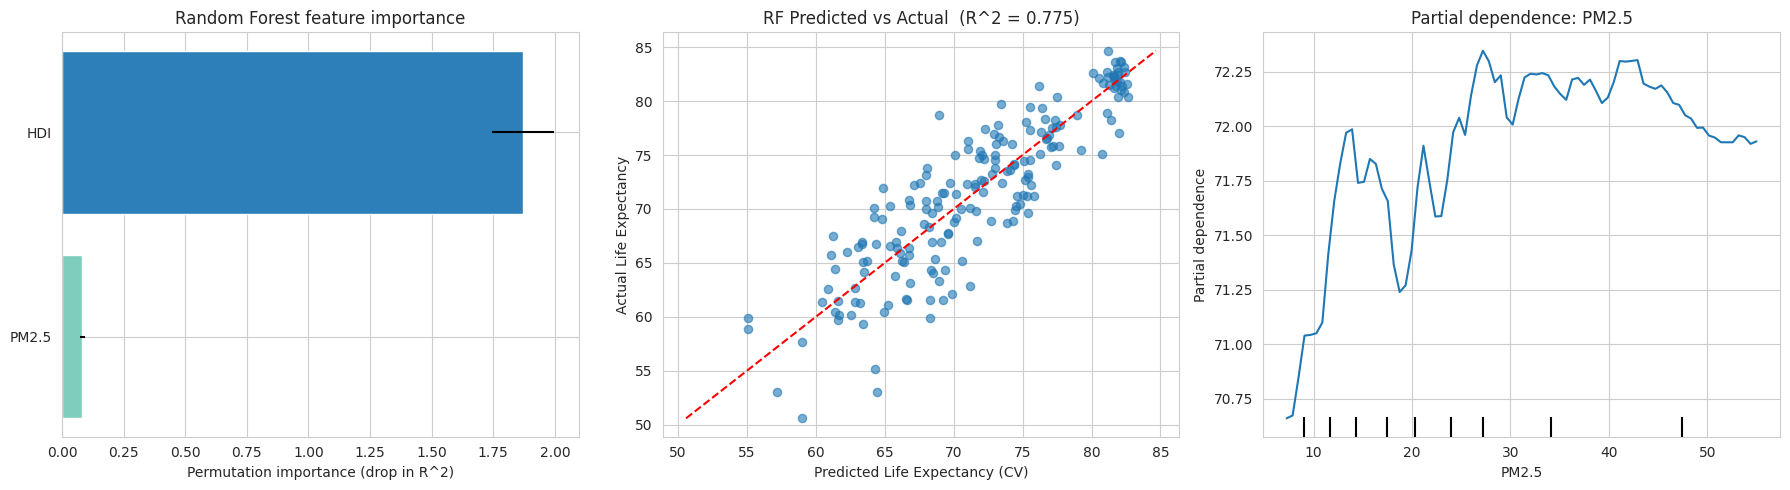

In [16]:
# Random Forest visualisations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = np.argsort(perm.importances_mean)[::-1]
axes[0].barh([feature_names[i] for i in order],
             perm.importances_mean[order],
             xerr=perm.importances_std[order],
             color=["#2c7fb8", "#7fcdbb"])
axes[0].set_xlabel("Permutation importance (drop in R^2)")
axes[0].set_title("Random Forest feature importance")
axes[0].invert_yaxis()

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1)
axes[1].scatter(y_pred_cv, y, alpha=0.6, s=35)
lo, hi = y.min(), y.max()
axes[1].plot([lo, hi], [lo, hi], "r--")
axes[1].set_xlabel("Predicted Life Expectancy (CV)")
axes[1].set_ylabel("Actual Life Expectancy")
axes[1].set_title(f"RF Predicted vs Actual  (R^2 = {r2_score(y, y_pred_cv):.3f})")

PartialDependenceDisplay.from_estimator(rf, X, [0],
                                        feature_names=feature_names,
                                        ax=axes[2], grid_resolution=80)
axes[2].set_title("Partial dependence: PM2.5")
axes[2].set_xlabel("PM2.5 (µg/m³)")
axes[2].set_ylabel("Predicted Life Expectancy")
plt.tight_layout(); plt.show()


METHOD 3 - K-MEANS CLUSTERING
k    inertia    silhouette
2     277.72      0.4403
3     195.29      0.3688
4     149.38      0.3519
5     115.12      0.3778
6      98.81      0.3447
7      85.91      0.3471
8      77.30      0.3396

Best k by silhouette score: k = 2



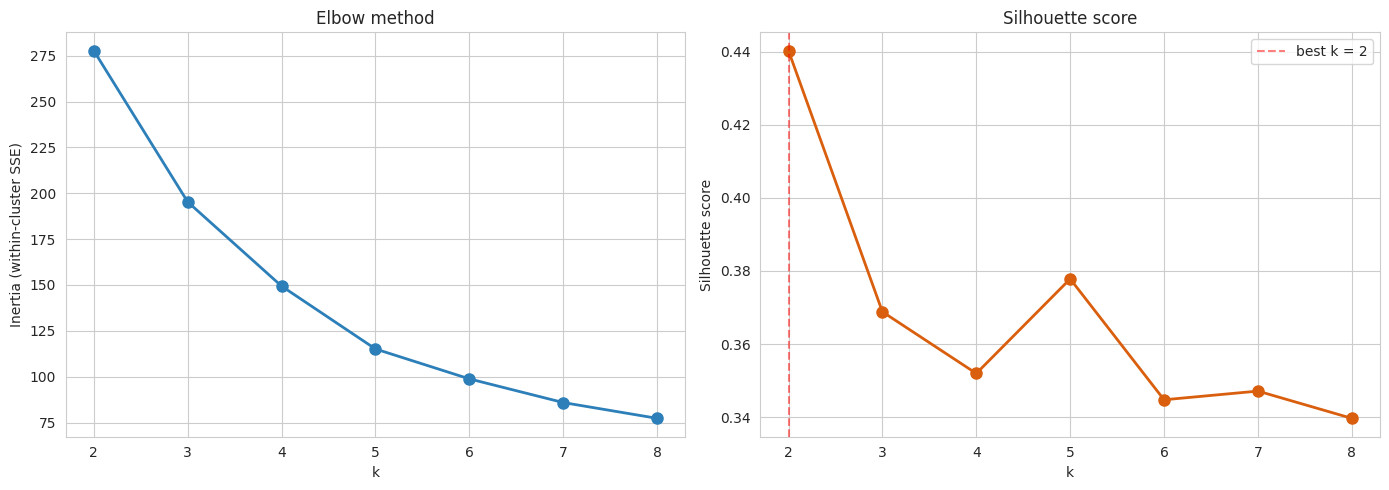

In [18]:
# METHOD 3 - K-MEANS CLUSTERING
# =============================================================
# Cluster countries on standardised [PM2.5, HDI, LifeExp].
# =============================================================
print("\n" + "="*60)
print("METHOD 3 - K-MEANS CLUSTERING")
print("="*60)

features = ["PM2_5", "HDI", "LifeExp"]
scaler = StandardScaler()
X_std  = scaler.fit_transform(df[features].values)

ks = list(range(2, 9))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_std)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std, labels))

print("k    inertia    silhouette")
for k, i, s in zip(ks, inertias, silhouettes):
    print(f"{k}   {i:8.2f}      {s:.4f}")

best_k = ks[int(np.argmax(silhouettes))]
print(f"\nBest k by silhouette score: k = {best_k}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, inertias, "o-", color="#2c7fb8", lw=2, markersize=8)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow method")

axes[1].plot(ks, silhouettes, "o-", color="#d95f0e", lw=2, markersize=8)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.5,
                label=f"best k = {best_k}")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")
axes[1].legend()
plt.tight_layout(); plt.show()



In [19]:
# Fit final K-Means and inspect clusters
final_k = best_k
km = KMeans(n_clusters=final_k, n_init=20, random_state=42)
df["Cluster"] = km.fit_predict(X_std)
sil_avg = silhouette_score(X_std, df["Cluster"])
print(f"\nFinal model: k = {final_k}, silhouette = {sil_avg:.4f}")

print("\nCluster centers (in original units):")
centers_orig = scaler.inverse_transform(km.cluster_centers_)
print(pd.DataFrame(centers_orig, columns=features,
                   index=[f"C{i}" for i in range(final_k)]).round(2))

print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster x HDI_Group cross-tab:")
print(pd.crosstab(df["Cluster"], df["HDI_Group"]))

print("\nCluster x Region cross-tab:")
print(pd.crosstab(df["Cluster"], df["Region"]))


Final model: k = 2, silhouette = 0.4403

Cluster centers (in original units):
    PM2_5   HDI  LifeExp
C0  18.14  0.82    76.11
C1  33.76  0.57    64.54

Cluster sizes:
Cluster
0    117
1     73
Name: count, dtype: int64

Cluster x HDI_Group cross-tab:
HDI_Group  High  Low  Medium  Very High
Cluster                                
0            45    0       6         66
1             5   27      41          0

Cluster x Region cross-tab:
Region   Africa  Asia  Europe  North America  Oceania  South America
Cluster                                                             
0             6    32      42             19        8             10
1            47    14       0              4        6              2


In [20]:
# METHOD 4 - PCA (2D summary)
# =============================================================
print("\n" + "="*60)
print("METHOD 4 - PCA (2D PROJECTION)")
print("="*60)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured by 2 PCs: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

print("\nPCA loadings (how each feature contributes to each PC):")
loadings = pd.DataFrame(pca.components_.T,
                        index=features, columns=["PC1", "PC2"]).round(3)
print(loadings)


METHOD 4 - PCA (2D PROJECTION)
Explained variance ratio: [0.773 0.197]
Total variance captured by 2 PCs: 97.0%

PCA loadings (how each feature contributes to each PC):
           PC1    PC2
PM2_5   -0.489  0.866
HDI      0.626  0.269
LifeExp  0.607  0.421


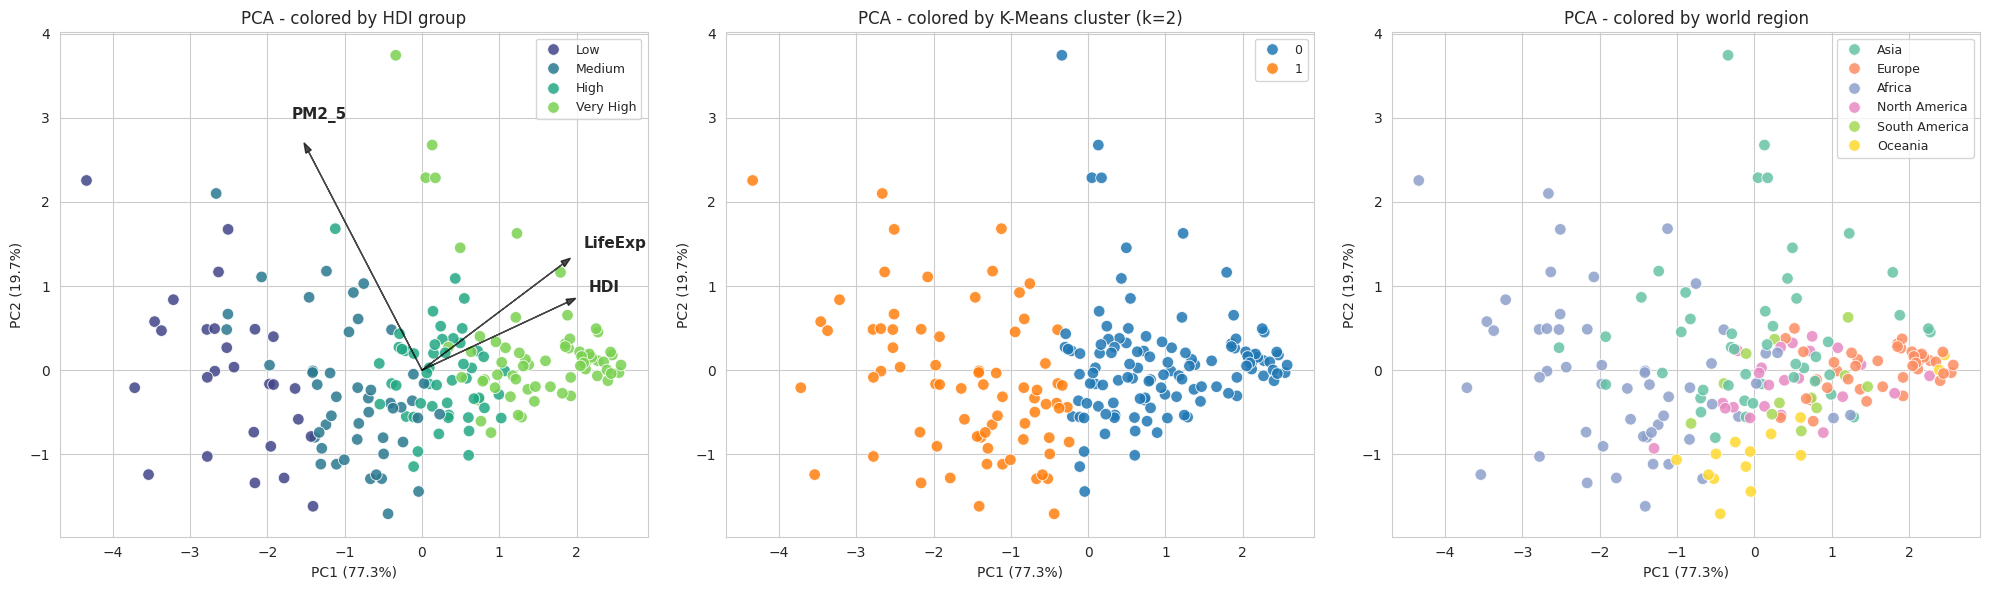

In [22]:
# PCA scatter plots: by HDI group, cluster, and region
df["PC1"], df["PC2"] = X_pca[:, 0], X_pca[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

hdi_order = ["Low", "Medium", "High", "Very High"]
sns.scatterplot(data=df, x="PC1", y="PC2",
                hue="HDI_Group", hue_order=hdi_order,
                palette="viridis", s=70, alpha=0.85, ax=axes[0])
axes[0].set_title("PCA - colored by HDI group")

sns.scatterplot(data=df, x="PC1", y="PC2",
                hue="Cluster",
                palette="tab10", s=70, alpha=0.85, ax=axes[1])
axes[1].set_title(f"PCA - colored by K-Means cluster (k={final_k})")

sns.scatterplot(data=df, x="PC1", y="PC2",
                hue="Region",
                palette="Set2", s=70, alpha=0.85, ax=axes[2])
axes[2].set_title("PCA - colored by world region")

# Loading vectors as arrows on the first plot
scale = 3.0
for i, feat in enumerate(features):
    axes[0].arrow(0, 0,
                  pca.components_[0, i] * scale,
                  pca.components_[1, i] * scale,
                  color="black", alpha=0.7, head_width=0.08)
    axes[0].text(pca.components_[0, i] * scale * 1.15,
                 pca.components_[1, i] * scale * 1.15,
                 feat, fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()

In [23]:
# Combined performance summary
# =============================================================
print("\n" + "="*60)
print("COMBINED PERFORMANCE SUMMARY")
print("="*60)

summary = pd.DataFrame({
    "Model":     ["Linear Regression M1 (PM2.5 only)",
                  "Linear Regression M2 (PM2.5 + HDI)",
                  "Linear Regression M3 (+ interaction)",
                  "Random Forest      (PM2.5 + HDI)"],
    "CV R^2":    [cv1[0], cv2[0], cv3[0], cv_r2_rf],
    "CV R^2 sd": [cv1[1], cv2[1], cv3[1], sd_r2_rf],
    "CV RMSE":   [cv1[2], cv2[2], cv3[2], cv_rmse_rf],
    "CV RMSE sd":[cv1[3], cv2[3], cv3[3], sd_rmse_rf],
})
print("\nSupervised regression -- predicting LifeExp:")
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print(f"\nClustering (K-Means, k = {final_k}):")
print(f"  Silhouette score: {sil_avg:.4f}")
print(f"  Cluster sizes   : "
      f"{dict(df['Cluster'].value_counts().sort_index())}")

print(f"\nDimensionality reduction (PCA):")
print(f"  Variance captured by 2 PCs: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")


COMBINED PERFORMANCE SUMMARY

Supervised regression -- predicting LifeExp:
                               Model  CV R^2  CV R^2 sd  CV RMSE  CV RMSE sd
   Linear Regression M1 (PM2.5 only)  0.1720     0.1718   6.4817      0.5973
  Linear Regression M2 (PM2.5 + HDI)  0.8062     0.0600   3.1092      0.3191
Linear Regression M3 (+ interaction)  0.8051     0.0596   3.1196      0.3287
    Random Forest      (PM2.5 + HDI)  0.7618     0.0869   3.4291      0.4252

Clustering (K-Means, k = 2):
  Silhouette score: 0.4403
  Cluster sizes   : {0: np.int64(117), 1: np.int64(73)}

Dimensionality reduction (PCA):
  Variance captured by 2 PCs: 97.0%


In [25]:
# Final interpretation
print("\n" + "="*60)
print("INTERPRETATION SUMMARY")
print("="*60)

b1_m1 = table1.loc[1, "coef"]
b1_m2 = table2.loc[1, "coef"]
p1_m2 = table2.loc[1, "p_value"]
b3_m3 = table3.loc[3, "coef"]
p3_m3 = table3.loc[3, "p_value"]
hdi_to_pm_ratio = perm.importances_mean[1] / perm.importances_mean[0]

print(f"""
LINEAR REGRESSION
- M1 (PM2.5 alone): a 1 ug/m3 increase in PM2.5 is associated with
  a {b1_m1:+.3f}-year change in life expectancy (highly significant).
- M2 (after adding HDI): the same 1 ug/m3 increase is associated
  with only {b1_m2:+.3f} years (p = {p1_m2:.3f}). The PM2.5 effect
  essentially vanishes -- strong evidence that HDI was confounding M1.
- M3 (with interaction): the PM2.5 x HDI term is {b3_m3:+.3f} with
  p = {p3_m3:.4f}, so there is no clear evidence of moderation.

RANDOM FOREST
- CV R^2 = {cv_r2_rf:.3f} (slightly lower than linear M2/M3, indicating
  the relationship is nearly linear and RF gains nothing from non-linearity).
- Permutation importance: HDI is roughly {hdi_to_pm_ratio:.0f}x more
  important than PM2.5 -- independent confirmation of the regression conclusion.

K-MEANS CLUSTERING
- The data naturally splits into k = {final_k} clusters along the
  development axis (rich/clean/long-lived vs poor/polluted/shorter-lived).

PCA
- 2 components capture {pca.explained_variance_ratio_.sum()*100:.1f}% of the variance.
- PC1 is essentially a 'development axis' (HDI and LifeExp positive,
  PM2.5 negative); PC2 is mostly residual PM2.5 variation.

OVERALL CONCLUSION
The cross-country relationship between PM2.5 and life expectancy
is largely a CONFOUNDING effect of HDI rather than a MODERATING one.
HDI alone explains ~82% of the variation in life expectancy, and
PM2.5 adds essentially nothing once HDI is in the model. Multiple
methods agree on this conclusion.
""")


INTERPRETATION SUMMARY

LINEAR REGRESSION
- M1 (PM2.5 alone): a 1 ug/m3 increase in PM2.5 is associated with
  a -0.233-year change in life expectancy (highly significant).
- M2 (after adding HDI): the same 1 ug/m3 increase is associated
  with only +0.024 years (p = 0.194). The PM2.5 effect
  essentially vanishes -- strong evidence that HDI was confounding M1.
- M3 (with interaction): the PM2.5 x HDI term is -0.036 with
  p = 0.6884, so there is no clear evidence of moderation.
 
RANDOM FOREST
- CV R^2 = 0.762 (slightly lower than linear M2/M3, indicating
  the relationship is nearly linear and RF gains nothing from non-linearity).
- Permutation importance: HDI is roughly 23x more
  important than PM2.5 -- independent confirmation of the regression conclusion.
 
K-MEANS CLUSTERING
- The data naturally splits into k = 2 clusters along the
  development axis (rich/clean/long-lived vs poor/polluted/shorter-lived).
 
PCA
- 2 components capture 97.0% of the variance.
- PC1 is essentially 